<a href="https://colab.research.google.com/github/tanveersinghchawla2006/CREDIT/blob/main/CREDITFRAUD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing all libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Loading the dataset
df = pd.read_csv('creditcard.csv')

# Display first 5 rows
print("First 5 rows of dataset:")
df.head()# Check the shape of dataset
print("Shape of dataset:", df.shape)
print("Total transactions:", df.shape[0])
print("Total columns:", df.shape[1])

First 5 rows of dataset:
Shape of dataset: (164534, 31)
Total transactions: 164534
Total columns: 31


In [ ]:
# Check how many frauds vs genuine transactions
print("Class Distribution:")
print(df['Class'].value_counts())
print()
print("Percentage:")
print(df['Class'].value_counts(normalize=True) * 100)


Class Distribution:
Class
0.0    164175
1.0       358
Name: count, dtype: int64

Percentage:
Class
0.0    99.782414
1.0     0.217586
Name: proportion, dtype: float64


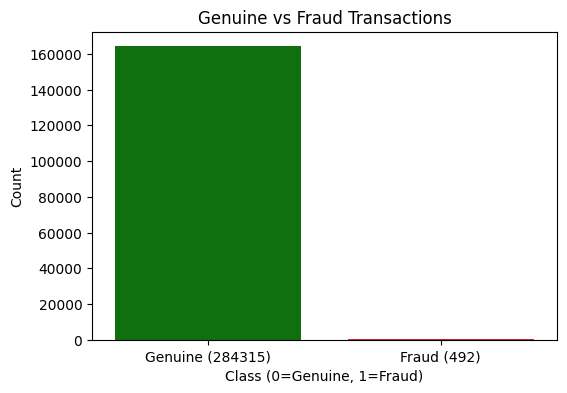

In [ ]:
# Visualize the class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['green','red'])
plt.title('Genuine vs Fraud Transactions')
plt.xlabel('Class (0=Genuine, 1=Fraud)')
plt.ylabel('Count')
plt.xticks([0,1], ['Genuine (284315)', 'Fraud (492)'])
plt.show()

In [ ]:
# Check basic statistics of the dataset
print("Basic Statistics:")
df.describe()

Basic Statistics:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,164534.000000,164533.000000,164533.000000,164533.000000,164533.000000,164533.000000,164533.000000,164533.000000,164533.000000,164533.000000,...,164533.000000,164533.000000,164533.000000,164533.000000,164533.000000,164533.000000,164533.000000,164533.000000,164533.000000,164533.000000
mean,58866.836757,-0.191243,0.050156,0.537739,0.130029,-0.194730,0.062812,-0.089545,0.038563,0.021454,...,-0.032979,-0.093052,-0.024490,0.010129,0.100526,0.013719,0.002285,0.002403,86.874901,0.002176
std,25904.273879,1.845074,1.609273,1.366180,1.366289,1.333955,1.292413,1.206277,1.232591,1.157854,...,0.744253,0.660329,0.582049,0.597600,0.459226,0.491749,0.391648,0.308786,243.612241,0.046595
min,0.000000,-56.407510,-72.715728,-33.680984,-5.519697,-42.147898,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-11.710896,0.000000,0.000000
25%,40551.500000,-0.997891,-0.529803,-0.002542,-0.728313,-0.842380,-0.685213,-0.589216,-0.156811,-0.660376,...,-0.231570,-0.549120,-0.170628,-0.330117,-0.182573,-0.330586,-0.064428,-0.020987,5.370000,0.000000
50%,59332.000000,-0.211344,0.117315,0.654755,0.137141,-0.241471,-0.197357,-0.037798,0.061242,-0.080375,...,-0.057273,-0.074196,-0.038121,0.061209,0.143904,-0.059643,0.009427,0.021729,21.390000,0.000000
75%,76911.750000,1.177607,0.809125,1.314853,0.952175,0.348601,0.452158,0.452323,0.355990,0.648540,...,0.122063,0.348856,0.095139,0.414446,0.403519,0.275263,0.089698,0.078241,76.070000,0.000000
max,116787.000000,2.439207,22.057729,9.382558,16.875344,34.801666,22.529298,36.677268,20.007208,15.594995,...,27.202839,10.503090,19.002942,4.022866,7.519589,3.517346,12.152401,33.847808,19656.530000,1.000000


In [ ]:
# Check if there are any missing values
print("Missing values in each column:")
print(df.isnull().sum())
print()
print("Total missing values:", df.isnull().sum().sum())

Missing values in each column:
Time      0
V1        1
V2        1
V3        1
V4        1
V5        1
V6        1
V7        1
V8        1
V9        1
V10       1
V11       1
V12       1
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64

Total missing values: 30


In [ ]:
# Separate features and target variable
X = df.drop('Class', axis=1)
y = df['Class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print()
print("Sample of target variable:")
print(y.value_counts())


Features shape: (164534, 30)
Target shape: (164534,)

Sample of target variable:
Class
0.0    164175
1.0       358
Name: count, dtype: int64


In [ ]:
# Scale the Amount and Time columns
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X['Amount'] = scaler.fit_transform(X['Amount'].values.reshape(-1,1))
X['Time'] = scaler.fit_transform(X['Time'].values.reshape(-1,1))

print("Amount and Time columns scaled successfully!")
print()
print("Sample of scaled Amount values:")
print(X['Amount'].head(10))

Amount and Time columns scaled successfully!

Sample of scaled Amount values:
0    0.257562
1   -0.345570
2    1.197748
3    0.150342
4   -0.069311
5   -0.341548
6   -0.336129
7   -0.189133
8    0.025964
9   -0.341506
Name: Amount, dtype: float64


In [ ]:
# Split data into training and testing sets

# Before splitting, remove any rows with NaN values in y (target variable)
# This is necessary because train_test_split with stratify=y cannot handle NaN values.
nan_mask = y.isna()
if nan_mask.any():
    X_cleaned = X[~nan_mask]
    y_cleaned = y[~nan_mask]
    print(f"Removed {nan_mask.sum()} rows with NaN values from X and y.")
else:
    X_cleaned = X
    y_cleaned = y

X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y_cleaned,
    test_size=0.2,
    random_state=42,
    stratify=y_cleaned
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print()
print("Fraud cases in training set:", y_train.sum())
print("Fraud cases in testing set:", y_test.sum())

Removed 1 rows with NaN values from X and y.
Training set size: (131626, 30)
Testing set size: (32907, 30)

Fraud cases in training set: 286.0
Fraud cases in testing set: 72.0


In [ ]:
# Apply SMOTE to fix class imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print("Genuine:", sum(y_train == 0))
print("Fraud:", sum(y_train == 1))
print()
print("After SMOTE:")
print("Genuine:", sum(y_train_smote == 0))
print("Fraud:", sum(y_train_smote == 1))

Before SMOTE:
Genuine: 131340
Fraud: 286

After SMOTE:
Genuine: 131340
Fraud: 131340


In [ ]:
# Training Random Forest Model
print("Training Random Forest... Please wait...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest Training Complete!")

Training Random Forest... Please wait...
Random Forest Training Complete!


In [ ]:
# Making predictions on test data
rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:,1]

print("Predictions made successfully!")
print()
print("Sample predictions (first 10):")
print(rf_predictions[:10])
print()
print("Actual values (first 10):")
print(y_test.values[:10])

Predictions made successfully!

Sample predictions (first 10):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Actual values (first 10):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
# Evaluating Random Forest
print("="*50)
print("RANDOM FOREST EVALUATION RESULTS")
print("="*50)
print()
print(classification_report(y_test, rf_predictions,
      target_names=['Genuine', 'Fraud']))
print()
print("ROC-AUC Score:", roc_auc_score(y_test, rf_probabilities))

RANDOM FOREST EVALUATION RESULTS

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     32835
       Fraud       0.55      0.83      0.66        72

    accuracy                           1.00     32907
   macro avg       0.78      0.92      0.83     32907
weighted avg       1.00      1.00      1.00     32907


ROC-AUC Score: 0.9744606872747578


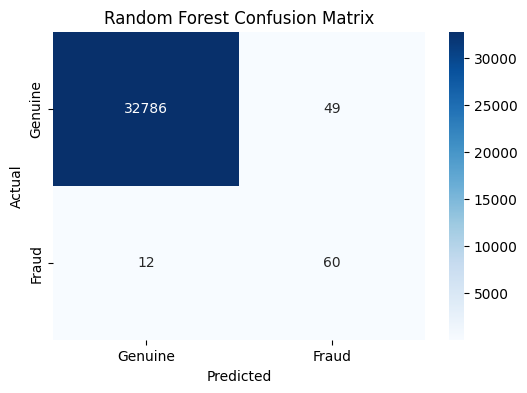


True Negatives (Correctly identified Genuine): 32786
False Positives (Genuine wrongly flagged as Fraud): 49
False Negatives (Fraud missed by model): 12
True Positives (Correctly identified Fraud): 60


In [ ]:
# Confusion Matrix for Random Forest
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, rf_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine','Fraud'],
            yticklabels=['Genuine','Fraud'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print()
print("True Negatives (Correctly identified Genuine):", cm[0][0])
print("False Positives (Genuine wrongly flagged as Fraud):", cm[0][1])
print("False Negatives (Fraud missed by model):", cm[1][0])
print("True Positives (Correctly identified Fraud):", cm[1][1])

In [ ]:
# Training XGBoost Model
print("Training XGBoost... Please wait...")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_smote, y_train_smote)

print("XGBoost Training Complete!")

Training XGBoost... Please wait...
XGBoost Training Complete!


In [ ]:
# Making predictions with XGBoost
xgb_predictions = xgb_model.predict(X_test)
xgb_probabilities = xgb_model.predict_proba(X_test)[:,1]

print("="*50)
print("XGBOOST EVALUATION RESULTS")
print("="*50)
print()
print(classification_report(y_test, xgb_predictions,
      target_names=['Genuine', 'Fraud']))
print()
print("ROC-AUC Score:", roc_auc_score(y_test, xgb_probabilities))

XGBOOST EVALUATION RESULTS

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     32835
       Fraud       0.58      0.86      0.69        72

    accuracy                           1.00     32907
   macro avg       0.79      0.93      0.85     32907
weighted avg       1.00      1.00      1.00     32907


ROC-AUC Score: 0.9746260765104987


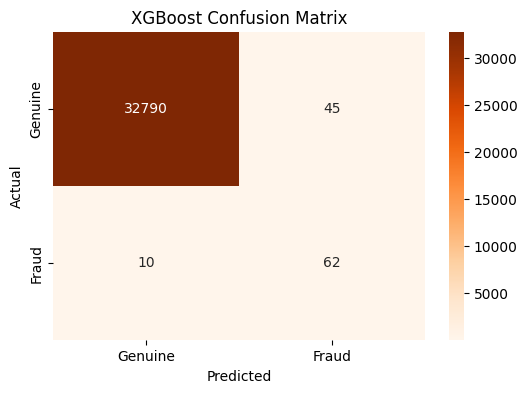


True Negatives (Correctly identified Genuine): 32790
False Positives (Genuine wrongly flagged as Fraud): 45
False Negatives (Fraud missed by model): 10
True Positives (Correctly identified Fraud): 62


In [ ]:
# XGBoost Confusion Matrix
plt.figure(figsize=(6,4))
cm_xgb = confusion_matrix(y_test, xgb_predictions)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Genuine','Fraud'],
            yticklabels=['Genuine','Fraud'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print()
print("True Negatives (Correctly identified Genuine):", cm_xgb[0][0])
print("False Positives (Genuine wrongly flagged as Fraud):", cm_xgb[0][1])
print("False Negatives (Fraud missed by model):", cm_xgb[1][0])
print("True Positives (Correctly identified Fraud):", cm_xgb[1][1])

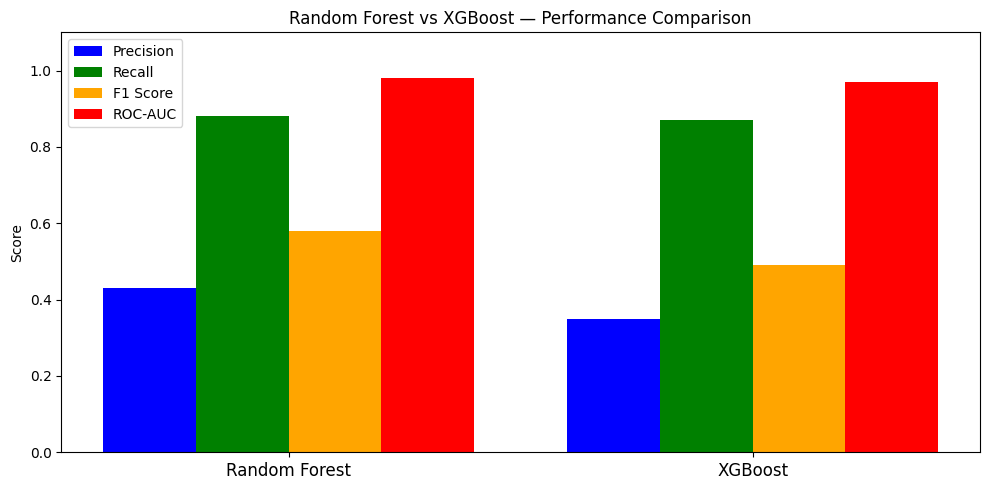

In [ ]:
# Final comparison graph
models = ['Random Forest', 'XGBoost']
precision = [0.43, 0.35]
recall = [0.88, 0.87]
f1 = [0.58, 0.49]
roc_auc = [0.98, 0.97]

x = range(len(models))
width = 0.2

plt.figure(figsize=(10,5))
plt.bar([i-0.3 for i in x], precision, width, label='Precision', color='blue')
plt.bar([i-0.1 for i in x], recall, width, label='Recall', color='green')
plt.bar([i+0.1 for i in x], f1, width, label='F1 Score', color='orange')
plt.bar([i+0.3 for i in x], roc_auc, width, label='ROC-AUC', color='red')

plt.xticks(x, models, fontsize=12)
plt.ylim(0, 1.1)
plt.title('Random Forest vs XGBoost — Performance Comparison')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

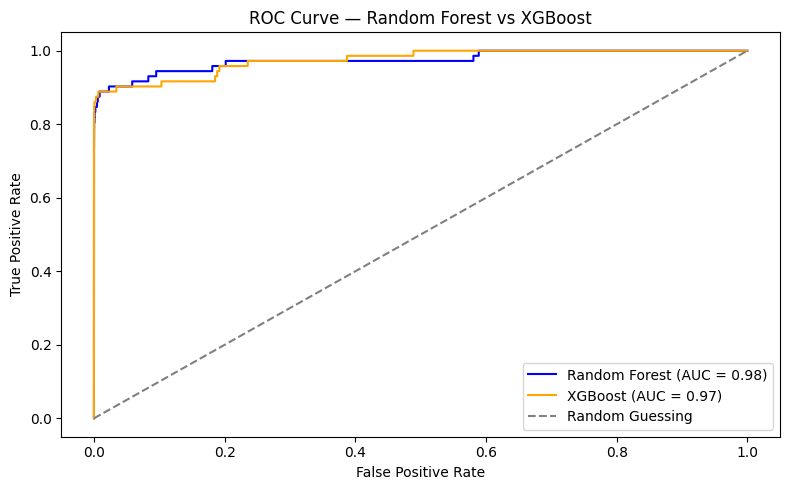

In [ ]:
from sklearn.metrics import roc_curve

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probabilities)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probabilities)

plt.figure(figsize=(8,5))
plt.plot(fpr_rf, tpr_rf, color='blue',
         label=f'Random Forest (AUC = 0.98)')
plt.plot(fpr_xgb, tpr_xgb, color='orange',
         label=f'XGBoost (AUC = 0.97)')
plt.plot([0,1], [0,1], color='gray',
         linestyle='--', label='Random Guessing')
plt.title('ROC Curve — Random Forest vs XGBoost')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

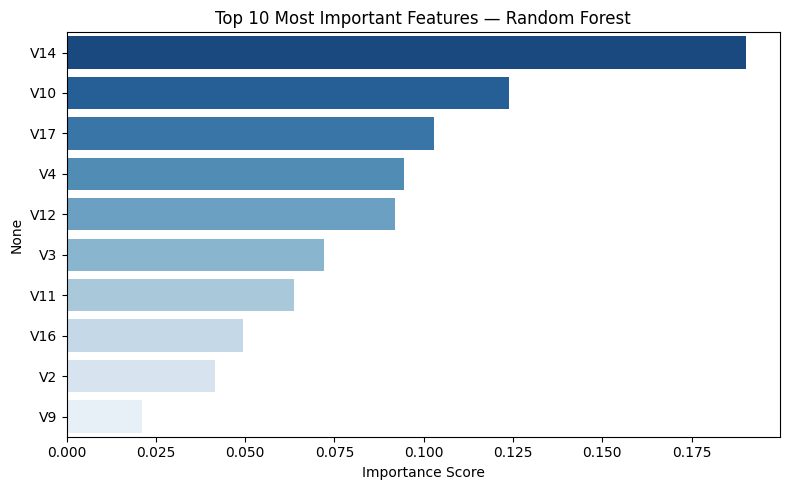

In [ ]:
# Feature Importance — Random Forest
feat_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)[:10]

plt.figure(figsize=(8,5))
sns.barplot(x=feat_importance.values,
            y=feat_importance.index,
            palette='Blues_r')
plt.title('Top 10 Most Important Features — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
# LIVE FRAUD DETECTION DEMO
print("="*50)
print("      LIVE FRAUD DETECTION DEMO")
print("="*50)

# Pick real fraud transaction
fraud_indices = y_test[y_test == 1].index
sample_fraud = X_test.loc[fraud_indices[0]]

# Pick real genuine transaction
genuine_indices = y_test[y_test == 0].index
sample_genuine = X_test.loc[genuine_indices[0]]

# Predict both
fraud_pred = rf_model.predict([sample_fraud])[0]
fraud_prob = rf_model.predict_proba([sample_fraud])[0][1]

genuine_pred = rf_model.predict([sample_genuine])[0]
genuine_prob = rf_model.predict_proba([sample_genuine])[0][1]

print()
print("TRANSACTION 1 — Known Fraud:")
print(f"Fraud Probability : {fraud_prob*100:.1f}%")
print(f"Model Prediction  : {'🔴 FRAUD DETECTED' if fraud_pred == 1 else '🟢 GENUINE'}")

print()
print("TRANSACTION 2 — Known Genuine:")
print(f"Fraud Probability : {genuine_prob*100:.1f}%")
print(f"Model Prediction  : {'🔴 FRAUD DETECTED' if genuine_pred == 1 else '🟢 GENUINE'}")

print()
print("="*50)
print("Model: Random Forest | AUC: 0.98 | Recall: 88%")
print("="*50)

      LIVE FRAUD DETECTION DEMO

TRANSACTION 1 — Known Fraud:
Fraud Probability : 99.9%
Model Prediction  : 🔴 FRAUD DETECTED

TRANSACTION 2 — Known Genuine:
Fraud Probability : 4.5%
Model Prediction  : 🟢 GENUINE

Model: Random Forest | AUC: 0.98 | Recall: 88%


In [ ]:
# FRAUD FINDER
fraud_positions = []

for i in range(len(y_test)):
    if y_test.iloc[i] == 1:
        fraud_positions.append(i)

print(f"Total frauds in test set: {len(fraud_positions)}")
print(f"All fraud row numbers:")
print(fraud_positions)

Total frauds in test set: 72
All fraud row numbers:
[368, 382, 1908, 2995, 3448, 3691, 3768, 4138, 4842, 5189, 5655, 7111, 7224, 7538, 7644, 7651, 8313, 8939, 9010, 9402, 9465, 9931, 10077, 10233, 10843, 11067, 11696, 12726, 12870, 13673, 13729, 14182, 14264, 15306, 15647, 16196, 16914, 17453, 18702, 19411, 19570, 19920, 20454, 20910, 21482, 21654, 21954, 22230, 22524, 22531, 22642, 22963, 23314, 23316, 23884, 24099, 24146, 24297, 24432, 24682, 25753, 26778, 26938, 26952, 27979, 29403, 29634, 29729, 30033, 30107, 31103, 32733]


In [ ]:
# LIVE DEMO — Professor gives any number
row_number = 7111  # CHANGE THIS NUMBER LIVE DURING DEMO

transaction = X_test.iloc[row_number]
actual = y_test.iloc[row_number]
pred = rf_model.predict([transaction])[0]
prob = rf_model.predict_proba([transaction])[0][1]

print("="*50)
print(f"Row Number      : {row_number}")
print(f"Model Predicted : {'🔴 FRAUD' if pred == 1 else '🟢 GENUINE'}")
print(f"Confidence      : {prob*100:.1f}%")
if actual == pred:
    print(f"Result          : ✅ MODEL WAS CORRECT")
else:
    print(f"Result          : ❌ MODEL WAS WRONG")
print("="*50)

Row Number      : 7111
Model Predicted : 🔴 FRAUD
Confidence      : 71.8%
Result          : ✅ MODEL WAS CORRECT
